In [1]:
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler  # 用来标准化数据
from sklearn.metrics import accuracy_score  # 评估模型性能

In [3]:
data = pd.read_csv("./data.csv")
data

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,fractal_dimension_mean,radius_se,texture_se,perimeter_se,area_se,smoothness_se,compactness_se,concavity_se,concave points_se,symmetry_se,fractal_dimension_se,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.30010,0.14710,0.2419,0.07871,1.0950,0.9053,8.589,153.40,0.006399,0.04904,0.05373,0.01587,0.03003,0.006193,25.380,17.33,184.60,2019.0,0.16220,0.66560,0.7119,0.2654,0.4601,0.11890
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.08690,0.07017,0.1812,0.05667,0.5435,0.7339,3.398,74.08,0.005225,0.01308,0.01860,0.01340,0.01389,0.003532,24.990,23.41,158.80,1956.0,0.12380,0.18660,0.2416,0.1860,0.2750,0.08902
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.19740,0.12790,0.2069,0.05999,0.7456,0.7869,4.585,94.03,0.006150,0.04006,0.03832,0.02058,0.02250,0.004571,23.570,25.53,152.50,1709.0,0.14440,0.42450,0.4504,0.2430,0.3613,0.08758
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.24140,0.10520,0.2597,0.09744,0.4956,1.1560,3.445,27.23,0.009110,0.07458,0.05661,0.01867,0.05963,0.009208,14.910,26.50,98.87,567.7,0.20980,0.86630,0.6869,0.2575,0.6638,0.17300
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.19800,0.10430,0.1809,0.05883,0.7572,0.7813,5.438,94.44,0.011490,0.02461,0.05688,0.01885,0.01756,0.005115,22.540,16.67,152.20,1575.0,0.13740,0.20500,0.4000,0.1625,0.2364,0.07678
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
564,926424,M,21.56,22.39,142.00,1479.0,0.11100,0.11590,0.24390,0.13890,0.1726,0.05623,1.1760,1.2560,7.673,158.70,0.010300,0.02891,0.05198,0.02454,0.01114,0.004239,25.450,26.40,166.10,2027.0,0.14100,0.21130,0.4107,0.2216,0.2060,0.07115
565,926682,M,20.13,28.25,131.20,1261.0,0.09780,0.10340,0.14400,0.09791,0.1752,0.05533,0.7655,2.4630,5.203,99.04,0.005769,0.02423,0.03950,0.01678,0.01898,0.002498,23.690,38.25,155.00,1731.0,0.11660,0.19220,0.3215,0.1628,0.2572,0.06637
566,926954,M,16.60,28.08,108.30,858.1,0.08455,0.10230,0.09251,0.05302,0.1590,0.05648,0.4564,1.0750,3.425,48.55,0.005903,0.03731,0.04730,0.01557,0.01318,0.003892,18.980,34.12,126.70,1124.0,0.11390,0.30940,0.3403,0.1418,0.2218,0.07820
567,927241,M,20.60,29.33,140.10,1265.0,0.11780,0.27700,0.35140,0.15200,0.2397,0.07016,0.7260,1.5950,5.772,86.22,0.006522,0.06158,0.07117,0.01664,0.02324,0.006185,25.740,39.42,184.60,1821.0,0.16500,0.86810,0.9387,0.2650,0.4087,0.12400


In [ ]:
# 删除无关的id列
data.drop("id", axis=1, inplace=True)
data

,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,fractal_dimension_mean,radius_se,texture_se,perimeter_se,area_se,smoothness_se,compactness_se,concavity_se,concave points_se,symmetry_se,fractal_dimension_se,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.30010,0.14710,0.2419,0.07871,1.0950,0.9053,8.589,153.40,0.006399,0.04904,0.05373,0.01587,0.03003,0.006193,25.380,17.33,184.60,2019.0,0.16220,0.66560,0.7119,0.2654,0.4601,0.11890
1,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.08690,0.07017,0.1812,0.05667,0.5435,0.7339,3.398,74.08,0.005225,0.01308,0.01860,0.01340,0.01389,0.003532,24.990,23.41,158.80,1956.0,0.12380,0.18660,0.2416,0.1860,0.2750,0.08902
2,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.19740,0.12790,0.2069,0.05999,0.7456,0.7869,4.585,94.03,0.006150,0.04006,0.03832,0.02058,0.02250,0.004571,23.570,25.53,152.50,1709.0,0.14440,0.42450,0.4504,0.2430,0.3613,0.08758
3,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.24140,0.10520,0.2597,0.09744,0.4956,1.1560,3.445,27.23,0.009110,0.07458,0.05661,0.01867,0.05963,0.009208,14.910,26.50,98.87,567.7,0.20980,0.86630,0.6869,0.2575,0.6638,0.17300
4,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.19800,0.10430,0.1809,0.05883,0.7572,0.7813,5.438,94.44,0.011490,0.02461,0.05688,0.01885,0.01756,0.005115,22.540,16.67,152.20,1575.0,0.13740,0.20500,0.4000,0.1625,0.2364,0.07678
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
564,M,21.56,22.39,142.00,1479.0,0.11100,0.11590,0.24390,0.13890,0.1726,0.05623,1.1760,1.2560,7.673,158.70,0.010300,0.02891,0.05198,0.02454,0.01114,0.004239,25.450,26.40,166.10,2027.0,0.14100,0.21130,0.4107,0.2216,0.2060,0.07115
565,M,20.13,28.25,131.20,1261.0,0.09780,0.10340,0.14400,0.09791,0.1752,0.05533,0.7655,2.4630,5.203,99.04,0.005769,0.02423,0.03950,0.01678,0.01898,0.002498,23.690,38.25,155.00,1731.0,0.11660,0.19220,0.3215,0.1628,0.2572,0.06637
566,M,16.60,28.08,108.30,858.1,0.08455,0.10230,0.09251,0.05302,0.1590,0.05648,0.4564,1.0750,3.425,48.55,0.005903,0.03731,0.04730,0.01557,0.01318,0.003892,18.980,34.12,126.70,1124.0,0.11390,0.30940,0.3403,0.1418,0.2218,0.07820
567,M,20.60,29.33,140.10,1265.0,0.11780,0.27700,0.35140,0.15200,0.2397,0.07016,0.7260,1.5950,5.772,86.22,0.006522,0.06158,0.07117,0.01664,0.02324,0.006185,25.740,39.42,184.60,1821.0,0.16500,0.86810,0.9387,0.2650,0.4087,0.12400


In [ ]:
# 将标签字段做映射，方便线性SVM分类，1和-1
data["diagnosis"] = data["diagnosis"].map({"B": -1, "M": 1})
data

,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,fractal_dimension_mean,radius_se,texture_se,perimeter_se,area_se,smoothness_se,compactness_se,concavity_se,concave points_se,symmetry_se,fractal_dimension_se,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,1,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.30010,0.14710,0.2419,0.07871,1.0950,0.9053,8.589,153.40,0.006399,0.04904,0.05373,0.01587,0.03003,0.006193,25.380,17.33,184.60,2019.0,0.16220,0.66560,0.7119,0.2654,0.4601,0.11890
1,1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.08690,0.07017,0.1812,0.05667,0.5435,0.7339,3.398,74.08,0.005225,0.01308,0.01860,0.01340,0.01389,0.003532,24.990,23.41,158.80,1956.0,0.12380,0.18660,0.2416,0.1860,0.2750,0.08902
2,1,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.19740,0.12790,0.2069,0.05999,0.7456,0.7869,4.585,94.03,0.006150,0.04006,0.03832,0.02058,0.02250,0.004571,23.570,25.53,152.50,1709.0,0.14440,0.42450,0.4504,0.2430,0.3613,0.08758
3,1,11.42,20.38,77.58,386.1,0.14250,0.28390,0.24140,0.10520,0.2597,0.09744,0.4956,1.1560,3.445,27.23,0.009110,0.07458,0.05661,0.01867,0.05963,0.009208,14.910,26.50,98.87,567.7,0.20980,0.86630,0.6869,0.2575,0.6638,0.17300
4,1,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.19800,0.10430,0.1809,0.05883,0.7572,0.7813,5.438,94.44,0.011490,0.02461,0.05688,0.01885,0.01756,0.005115,22.540,16.67,152.20,1575.0,0.13740,0.20500,0.4000,0.1625,0.2364,0.07678
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
564,1,21.56,22.39,142.00,1479.0,0.11100,0.11590,0.24390,0.13890,0.1726,0.05623,1.1760,1.2560,7.673,158.70,0.010300,0.02891,0.05198,0.02454,0.01114,0.004239,25.450,26.40,166.10,2027.0,0.14100,0.21130,0.4107,0.2216,0.2060,0.07115
565,1,20.13,28.25,131.20,1261.0,0.09780,0.10340,0.14400,0.09791,0.1752,0.05533,0.7655,2.4630,5.203,99.04,0.005769,0.02423,0.03950,0.01678,0.01898,0.002498,23.690,38.25,155.00,1731.0,0.11660,0.19220,0.3215,0.1628,0.2572,0.06637
566,1,16.60,28.08,108.30,858.1,0.08455,0.10230,0.09251,0.05302,0.1590,0.05648,0.4564,1.0750,3.425,48.55,0.005903,0.03731,0.04730,0.01557,0.01318,0.003892,18.980,34.12,126.70,1124.0,0.11390,0.30940,0.3403,0.1418,0.2218,0.07820
567,1,20.60,29.33,140.10,1265.0,0.11780,0.27700,0.35140,0.15200,0.2397,0.07016,0.7260,1.5950,5.772,86.22,0.006522,0.06158,0.07117,0.01664,0.02324,0.006185,25.740,39.42,184.60,1821.0,0.16500,0.86810,0.9387,0.2650,0.4087,0.12400


In [6]:
# 通过一些方法筛选特征，这里直接保留这几个
features = [
    "radius_mean",
    "texture_mean",
    "smoothness_mean",
    "compactness_mean",
    "symmetry_mean",
    "fractal_dimension_mean"
]

In [12]:
# 构造特征矩阵（样本数，特征数）
X = data[features].values
X = X.astype(np.float64)
X

array([[17.99   , 10.38   ,  0.1184 ,  0.2776 ,  0.2419 ,  0.07871],
       [20.57   , 17.77   ,  0.08474,  0.07864,  0.1812 ,  0.05667],
       [19.69   , 21.25   ,  0.1096 ,  0.1599 ,  0.2069 ,  0.05999],
       ...,
       [16.6    , 28.08   ,  0.08455,  0.1023 ,  0.159  ,  0.05648],
       [20.6    , 29.33   ,  0.1178 ,  0.277  ,  0.2397 ,  0.07016],
       [ 7.76   , 24.54   ,  0.05263,  0.04362,  0.1587 ,  0.05884]],
      shape=(569, 6))

In [13]:
y = data["diagnosis"].values
y = y.astype(np.float64)
y

array([ 1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,
        1.,  1.,  1.,  1.,  1.,  1., -1., -1., -1.,  1.,  1.,  1.,  1.,
        1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,  1., -1.,  1.,
        1.,  1.,  1.,  1.,  1.,  1.,  1., -1.,  1., -1., -1., -1., -1.,
       -1.,  1.,  1., -1.,  1.,  1., -1., -1., -1., -1.,  1., -1.,  1.,
        1., -1., -1., -1., -1.,  1., -1.,  1.,  1., -1.,  1., -1.,  1.,
        1., -1., -1., -1.,  1.,  1., -1.,  1.,  1.,  1., -1., -1., -1.,
        1., -1., -1.,  1.,  1., -1., -1., -1.,  1.,  1., -1., -1., -1.,
       -1.,  1., -1., -1.,  1., -1., -1., -1., -1., -1., -1., -1., -1.,
        1.,  1.,  1., -1.,  1.,  1., -1., -1., -1.,  1.,  1., -1.,  1.,
       -1.,  1.,  1., -1.,  1.,  1., -1., -1.,  1., -1., -1.,  1., -1.,
       -1., -1., -1.,  1., -1., -1., -1., -1., -1., -1., -1., -1., -1.,
        1., -1., -1., -1., -1.,  1.,  1., -1.,  1., -1., -1.,  1.,  1.,
       -1., -1.,  1.,  1., -1., -1., -1., -1.,  1., -1., -1.,  1

In [11]:
y.shape

(569,)

In [ ]:
# 变成合适的维度避免广播机制
if y.ndim == 1:
    y = y.reshape(-1, 1)

In [15]:
y.shape

(569, 1)

In [17]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.3,
    random_state=42
)

In [18]:
X_train

array([[13.74   , 17.91   ,  0.07944,  0.06376,  0.1473 ,  0.0558 ],
       [13.37   , 16.39   ,  0.07115,  0.07325,  0.1422 ,  0.05823],
       [14.69   , 13.98   ,  0.1031 ,  0.1836 ,  0.2086 ,  0.07406],
       ...,
       [14.29   , 16.82   ,  0.06429,  0.02675,  0.1508 ,  0.05376],
       [13.98   , 19.62   ,  0.106  ,  0.1133 ,  0.1669 ,  0.06544],
       [12.18   , 20.52   ,  0.08013,  0.04038,  0.1739 ,  0.05677]],
      shape=(398, 6))

In [19]:
y_train

array([[-1.],
       [-1.],
       [-1.],
       [-1.],
       [-1.],
       [ 1.],
       [-1.],
       [-1.],
       [-1.],
       [-1.],
       [-1.],
       [-1.],
       [ 1.],
       [ 1.],
       [ 1.],
       [-1.],
       [-1.],
       [ 1.],
       [-1.],
       [ 1.],
       [-1.],
       [-1.],
       [-1.],
       [-1.],
       [ 1.],
       [-1.],
       [-1.],
       [ 1.],
       [-1.],
       [-1.],
       [-1.],
       [ 1.],
       [-1.],
       [ 1.],
       [ 1.],
       [-1.],
       [-1.],
       [-1.],
       [ 1.],
       [-1.],
       [-1.],
       [-1.],
       [-1.],
       [ 1.],
       [-1.],
       [-1.],
       [-1.],
       [-1.],
       [-1.],
       [ 1.],
       [-1.],
       [ 1.],
       [ 1.],
       [-1.],
       [-1.],
       [ 1.],
       [-1.],
       [-1.],
       [-1.],
       [-1.],
       [-1.],
       [-1.],
       [-1.],
       [ 1.],
       [ 1.],
       [ 1.],
       [-1.],
       [-1.],
       [ 1.],
       [-1.],
       [-1.],
      

In [21]:
# 标准化
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [47]:
class LinearSVM:
    def __init__(self, C=1.0, lr=1e-3, epochs=1000):
        self.C = C
        self.lr = lr
        self.epochs = epochs

        self.w = None
        self.b = None

        self.loss_history = []

    def decision_function(self, X):
        return X @ self.w + self.b

    # sign是符号函数，scores大于0返回1，小于0返回-1
    def predict(self, X):
        scores = self.decision_function(X)
        return np.sign(scores)

    # 一个样本的hinge_loss
    def hinge_loss_single(self, x, y):
        score = np.dot(self.w, x) + self.b
        return max(0.0, 1 - y * score)

    # 计算所有样本的
    def hinge_loss(self, X, y):
        loss = 0.0
        for i in range(len(y)):
            loss += self.hinge_loss_single(X[i], y[i])
        return loss

    # 线性约束下原始问题的优化目标
    def objective(self, X, y):
        reg = 0.5 * np.dot(self.w, self.w)
        loss = self.hinge_loss(X, y)
        return reg + self.C * loss

    def fit(self, X, y):
        self.loss_history = []
        n_samples, n_features = X.shape

        # 初始化参数
        self.w = np.zeros(n_features)
        self.b = 0.0

        for epoch in range(self.epochs):
            
            for i in range(n_samples):
                x_i = X[i]
                y_i = y[i]

                margin = y_i * (np.dot(self.w, x_i) + self.b)

                if margin >= 1:
                    self.w -= self.lr * self.w
                    # 这个时候对b的梯度为0
                else:
                    self.w -= self.lr * (self.w - self.C * y_i * x_i)
                    self.b -= self.lr * (- self.C * y_i)
            
            self.loss_history.append(self.objective(X, y))

In [48]:
svm = LinearSVM(C=1.0, lr=1e-3, epochs=1000)
svm.fit(X_train, y_train)

In [49]:
y_pred = svm.predict(X_test)

accuracy = (y_pred == y_test).mean()
print("Test Accuracy:", accuracy)

Test Accuracy: 0.3684210526315789


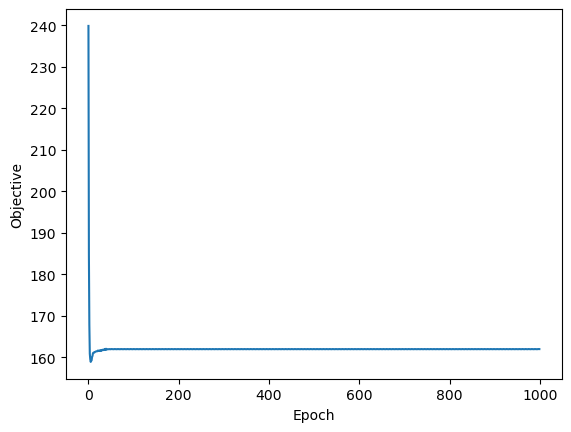

In [50]:
plt.plot(svm.loss_history)
plt.xlabel("Epoch")
plt.ylabel("Objective")
plt.show()

In [51]:
# 上面是手写线性SVM，效果不是很好，扯了半天，现在回到调包、
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC # 直接掉包SVM
from sklearn.metrics import accuracy_score


In [55]:
# 读取数据
data = pd.read_csv("./data.csv")

# 删除无关列
data.drop("id", axis=1, inplace=True)

# 标签映射（与学姐一致：B=0, M=1）
data["diagnosis"] = data["diagnosis"].map({"B": 0, "M": 1})

data

,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,fractal_dimension_mean,radius_se,texture_se,perimeter_se,area_se,smoothness_se,compactness_se,concavity_se,concave points_se,symmetry_se,fractal_dimension_se,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,1,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.30010,0.14710,0.2419,0.07871,1.0950,0.9053,8.589,153.40,0.006399,0.04904,0.05373,0.01587,0.03003,0.006193,25.380,17.33,184.60,2019.0,0.16220,0.66560,0.7119,0.2654,0.4601,0.11890
1,1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.08690,0.07017,0.1812,0.05667,0.5435,0.7339,3.398,74.08,0.005225,0.01308,0.01860,0.01340,0.01389,0.003532,24.990,23.41,158.80,1956.0,0.12380,0.18660,0.2416,0.1860,0.2750,0.08902
2,1,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.19740,0.12790,0.2069,0.05999,0.7456,0.7869,4.585,94.03,0.006150,0.04006,0.03832,0.02058,0.02250,0.004571,23.570,25.53,152.50,1709.0,0.14440,0.42450,0.4504,0.2430,0.3613,0.08758
3,1,11.42,20.38,77.58,386.1,0.14250,0.28390,0.24140,0.10520,0.2597,0.09744,0.4956,1.1560,3.445,27.23,0.009110,0.07458,0.05661,0.01867,0.05963,0.009208,14.910,26.50,98.87,567.7,0.20980,0.86630,0.6869,0.2575,0.6638,0.17300
4,1,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.19800,0.10430,0.1809,0.05883,0.7572,0.7813,5.438,94.44,0.011490,0.02461,0.05688,0.01885,0.01756,0.005115,22.540,16.67,152.20,1575.0,0.13740,0.20500,0.4000,0.1625,0.2364,0.07678
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
564,1,21.56,22.39,142.00,1479.0,0.11100,0.11590,0.24390,0.13890,0.1726,0.05623,1.1760,1.2560,7.673,158.70,0.010300,0.02891,0.05198,0.02454,0.01114,0.004239,25.450,26.40,166.10,2027.0,0.14100,0.21130,0.4107,0.2216,0.2060,0.07115
565,1,20.13,28.25,131.20,1261.0,0.09780,0.10340,0.14400,0.09791,0.1752,0.05533,0.7655,2.4630,5.203,99.04,0.005769,0.02423,0.03950,0.01678,0.01898,0.002498,23.690,38.25,155.00,1731.0,0.11660,0.19220,0.3215,0.1628,0.2572,0.06637
566,1,16.60,28.08,108.30,858.1,0.08455,0.10230,0.09251,0.05302,0.1590,0.05648,0.4564,1.0750,3.425,48.55,0.005903,0.03731,0.04730,0.01557,0.01318,0.003892,18.980,34.12,126.70,1124.0,0.11390,0.30940,0.3403,0.1418,0.2218,0.07820
567,1,20.60,29.33,140.10,1265.0,0.11780,0.27700,0.35140,0.15200,0.2397,0.07016,0.7260,1.5950,5.772,86.22,0.006522,0.06158,0.07117,0.01664,0.02324,0.006185,25.740,39.42,184.60,1821.0,0.16500,0.86810,0.9387,0.2650,0.4087,0.12400


In [84]:
import matplotlib.pyplot as plt
import seaborn as sns

# 提取 mean 特征（和学姐一致）
features_mean = list(data.columns[1:11])  # diagnosis 后面的 10 个 mean 特征
features_mean

['radius_mean',
 'texture_mean',
 'perimeter_mean',
 'area_mean',
 'smoothness_mean',
 'compactness_mean',
 'concavity_mean',
 'concave points_mean',
 'symmetry_mean',
 'fractal_dimension_mean']

In [ ]:
# corr()计算皮尔逊相关系数矩阵
corr_matrix = data[features_mean].corr()
corr_matrix

,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,fractal_dimension_mean
radius_mean,1.000000,0.323782,0.997855,0.987357,0.170581,0.506124,0.676764,0.822529,0.147741,-0.311631
texture_mean,0.323782,1.000000,0.329533,0.321086,-0.023389,0.236702,0.302418,0.293464,0.071401,-0.076437
perimeter_mean,0.997855,0.329533,1.000000,0.986507,0.207278,0.556936,0.716136,0.850977,0.183027,-0.261477
area_mean,0.987357,0.321086,0.986507,1.000000,0.177028,0.498502,0.685983,0.823269,0.151293,-0.283110
smoothness_mean,0.170581,-0.023389,0.207278,0.177028,1.000000,0.659123,0.521984,0.553695,0.557775,0.584792
compactness_mean,0.506124,0.236702,0.556936,0.498502,0.659123,1.000000,0.883121,0.831135,0.602641,0.565369
concavity_mean,0.676764,0.302418,0.716136,0.685983,0.521984,0.883121,1.000000,0.921391,0.500667,0.336783
concave points_mean,0.822529,0.293464,0.850977,0.823269,0.553695,0.831135,0.921391,1.000000,0.462497,0.166917
symmetry_mean,0.147741,0.071401,0.183027,0.151293,0.557775,0.602641,0.500667,0.462497,1.000000,0.479921
fractal_dimension_mean,-0.311631,-0.076437,-0.261477,-0.283110,0.584792,0.565369,0.336783,0.166917,0.479921,1.000000


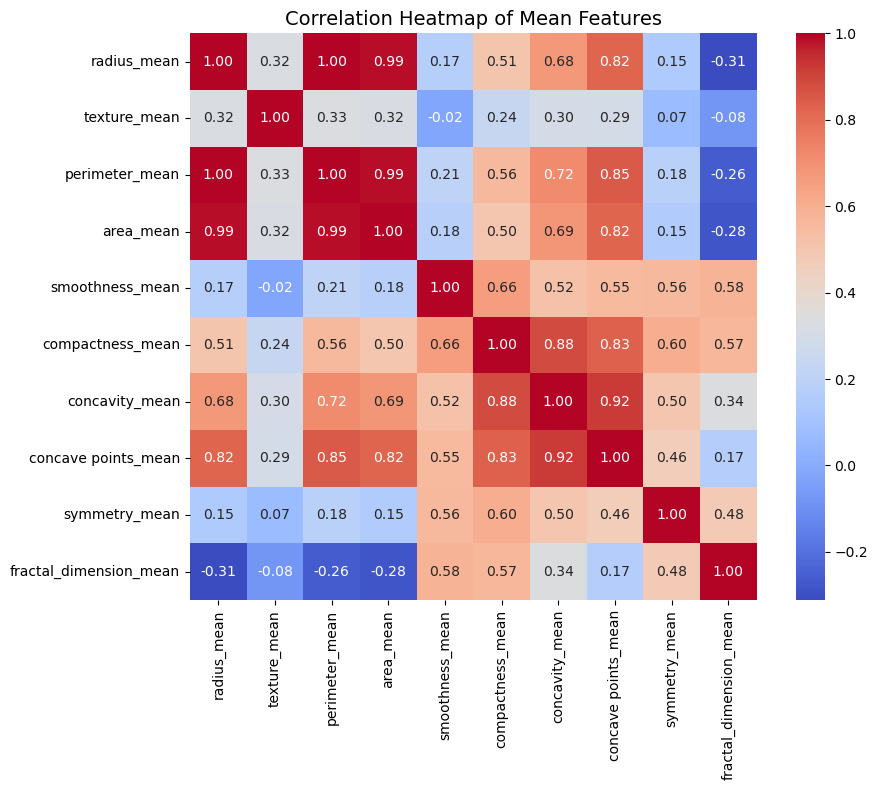

In [86]:
plt.figure(figsize=(10, 8))

sns.heatmap(
    corr_matrix,
    cmap="coolwarm",      # 红-蓝对称，更适合相关性
    annot=True,           # 显示数值
    fmt=".2f",            # 保留两位小数
    square=True,
    cbar=True
)

plt.title("Correlation Heatmap of Mean Features", fontsize=14)
plt.tight_layout()
plt.show()


In [56]:
features = [
    "radius_mean",
    "texture_mean",
    "smoothness_mean",
    "compactness_mean",
    "symmetry_mean",
    "fractal_dimension_mean"
]

X = data[features]
y = data["diagnosis"]


In [57]:
X

,radius_mean,texture_mean,smoothness_mean,compactness_mean,symmetry_mean,fractal_dimension_mean
0,17.99,10.38,0.11840,0.27760,0.2419,0.07871
1,20.57,17.77,0.08474,0.07864,0.1812,0.05667
2,19.69,21.25,0.10960,0.15990,0.2069,0.05999
3,11.42,20.38,0.14250,0.28390,0.2597,0.09744
4,20.29,14.34,0.10030,0.13280,0.1809,0.05883
...,...,...,...,...,...,...
564,21.56,22.39,0.11100,0.11590,0.1726,0.05623
565,20.13,28.25,0.09780,0.10340,0.1752,0.05533
566,16.60,28.08,0.08455,0.10230,0.1590,0.05648
567,20.60,29.33,0.11780,0.27700,0.2397,0.07016


In [58]:
y

0      1
1      1
2      1
3      1
4      1
      ..
564    1
565    1
566    1
567    1
568    0
Name: diagnosis, Length: 569, dtype: int64

In [59]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


In [71]:
import pandas as pd
from sklearn.metrics import confusion_matrix

results = []

for kernel in kernels:
    svm = SVC(kernel=kernel, random_state=42)
    svm.fit(X_train, y_train)
    y_pred = svm.predict(X_test)

    tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()

    precision = tp / (tp + fp) if (tp + fp) != 0 else 0.0
    recall = tp / (tp + fn) if (tp + fn) != 0 else 0.0
    f1 = (2 * precision * recall / (precision + recall)
          if (precision + recall) != 0 else 0.0)

    results.append({
        "Kernel": kernel,
        "TN": tn,
        "FP": fp,
        "FN": fn,
        "TP": tp,
        "Accuracy": (tp + tn) / (tp + tn + fp + fn),
        "Precision": precision,
        "Recall": recall,
        "F1-score": f1
    })

df_metrics = pd.DataFrame(results)
df_metrics


,Kernel,TN,FP,FN,TP,Accuracy,Precision,Recall,F1-score
0,linear,106,2,5,58,0.959064,0.966667,0.920635,0.943089
1,poly,107,1,17,46,0.894737,0.978723,0.730159,0.836364
2,rbf,106,2,4,59,0.964912,0.967213,0.936508,0.951613
3,sigmoid,97,11,15,48,0.847953,0.813559,0.761905,0.786885


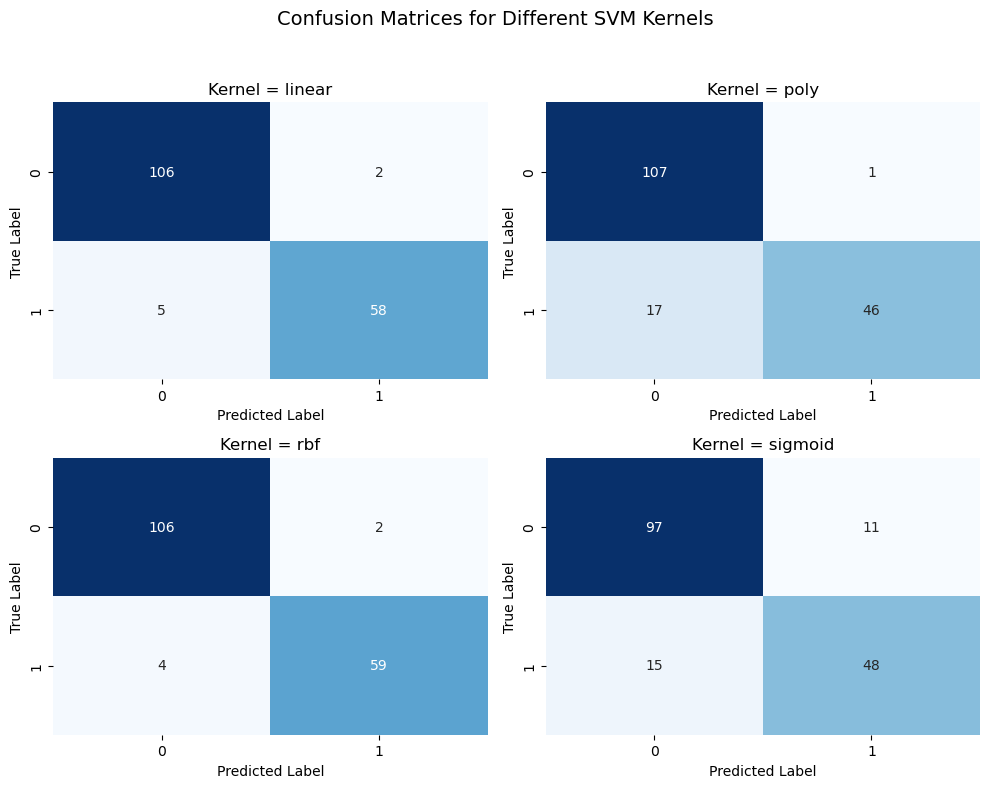

In [70]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

kernels = ['linear', 'poly', 'rbf', 'sigmoid']

fig, axes = plt.subplots(2, 2, figsize=(10, 8))
axes = axes.flatten()

for idx, kernel in enumerate(kernels):
    svm = SVC(kernel=kernel, random_state=42)
    svm.fit(X_train, y_train)
    y_pred = svm.predict(X_test)

    cm = confusion_matrix(y_test, y_pred)

    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        cbar=False,
        ax=axes[idx]
    )

    axes[idx].set_title(f"Kernel = {kernel}")
    axes[idx].set_xlabel("Predicted Label")
    axes[idx].set_ylabel("True Label")

plt.suptitle("Confusion Matrices for Different SVM Kernels", fontsize=14)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()


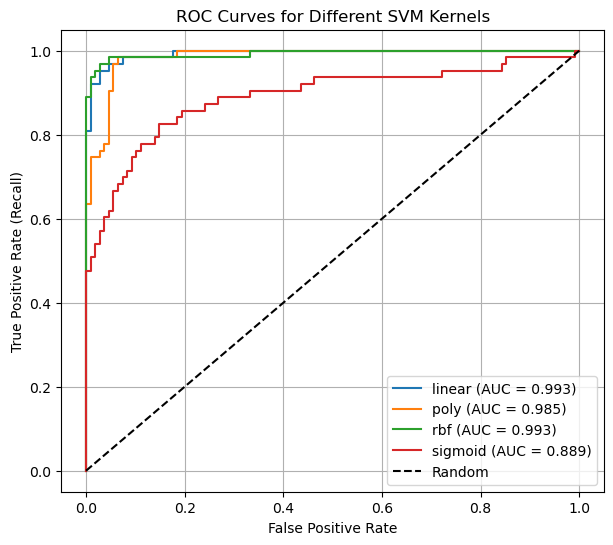

In [72]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

plt.figure(figsize=(7, 6))

for kernel in kernels:
    svm = SVC(kernel=kernel, probability=True, random_state=42)
    svm.fit(X_train, y_train)

    # 正类（恶性 = 1）的预测概率
    y_score = svm.predict_proba(X_test)[:, 1]

    fpr, tpr, _ = roc_curve(y_test, y_score)
    roc_auc = auc(fpr, tpr)

    plt.plot(fpr, tpr, label=f"{kernel} (AUC = {roc_auc:.3f})")

# 随机分类参考线
plt.plot([0, 1], [0, 1], 'k--', label="Random")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate (Recall)")
plt.title("ROC Curves for Different SVM Kernels")
plt.legend(loc="lower right")
plt.grid(True)
plt.show()


In [81]:
# 研究C值对模型的影响，线性SVM
C_values = [0.001, 0.01, 0.1, 1, 10, 100, 1000]

In [82]:
from sklearn.metrics import accuracy_score, recall_score

acc_list = []
recall_list = []

for C in C_values:
    svm = SVC(kernel='linear', C=C, random_state=42)
    svm.fit(X_train, y_train)

    y_pred = svm.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)  # 默认正类是 1（恶性）

    acc_list.append(acc)
    recall_list.append(recall)

acc_list, recall_list


([0.6842105263157895,
  0.935672514619883,
  0.9532163742690059,
  0.9590643274853801,
  0.9532163742690059,
  0.9532163742690059,
  0.9532163742690059],
 [0.14285714285714285,
  0.8412698412698413,
  0.8888888888888888,
  0.9206349206349206,
  0.9206349206349206,
  0.9206349206349206,
  0.9206349206349206])

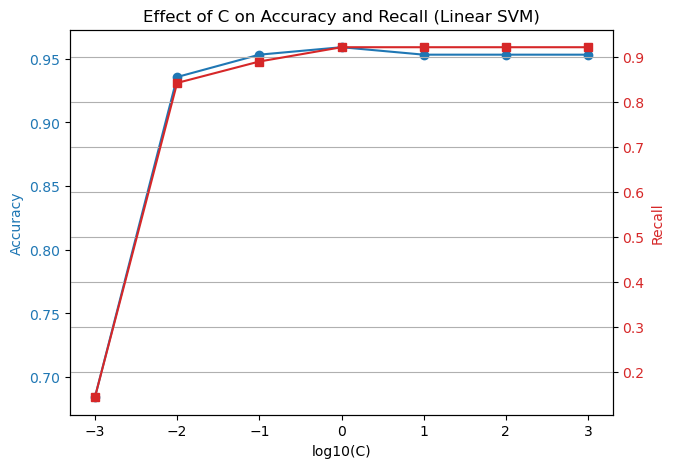

In [83]:
import matplotlib.pyplot as plt
import numpy as np

C_log = np.log10(C_values)

fig, ax1 = plt.subplots(figsize=(7, 5))

ax1.plot(C_log, acc_list, marker='o', color='tab:blue', label='Accuracy')
ax1.set_xlabel("log10(C)")
ax1.set_ylabel("Accuracy", color='tab:blue')
ax1.tick_params(axis='y', labelcolor='tab:blue')

ax2 = ax1.twinx()
ax2.plot(C_log, recall_list, marker='s', color='tab:red', label='Recall')
ax2.set_ylabel("Recall", color='tab:red')
ax2.tick_params(axis='y', labelcolor='tab:red')

plt.title("Effect of C on Accuracy and Recall (Linear SVM)")
plt.grid(True)
plt.show()



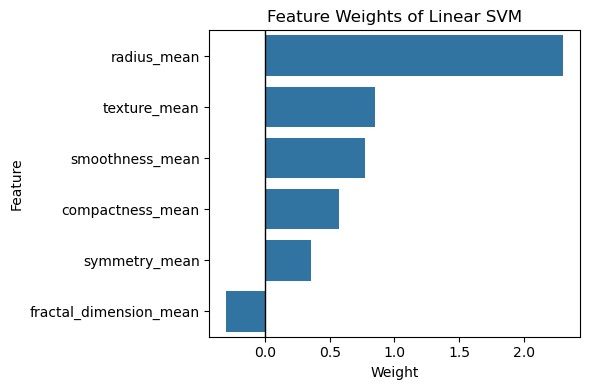

In [ ]:
# 线性SVM是可解释的，权重图
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
import numpy as np

# 特征和标签
X = data[features]
y = data["diagnosis"]

# 标准化（非常关键）
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 训练线性 SVM
svm_linear = SVC(kernel="linear", C=1.0)
svm_linear.fit(X_scaled, y)

# 提取权重
weights = svm_linear.coef_[0]

# 作图
plt.figure(figsize=(6, 4))
sns.barplot(x=weights, y=features, orient="h")
plt.axvline(0, color="black", linewidth=1)

plt.title("Feature Weights of Linear SVM")
plt.xlabel("Weight")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

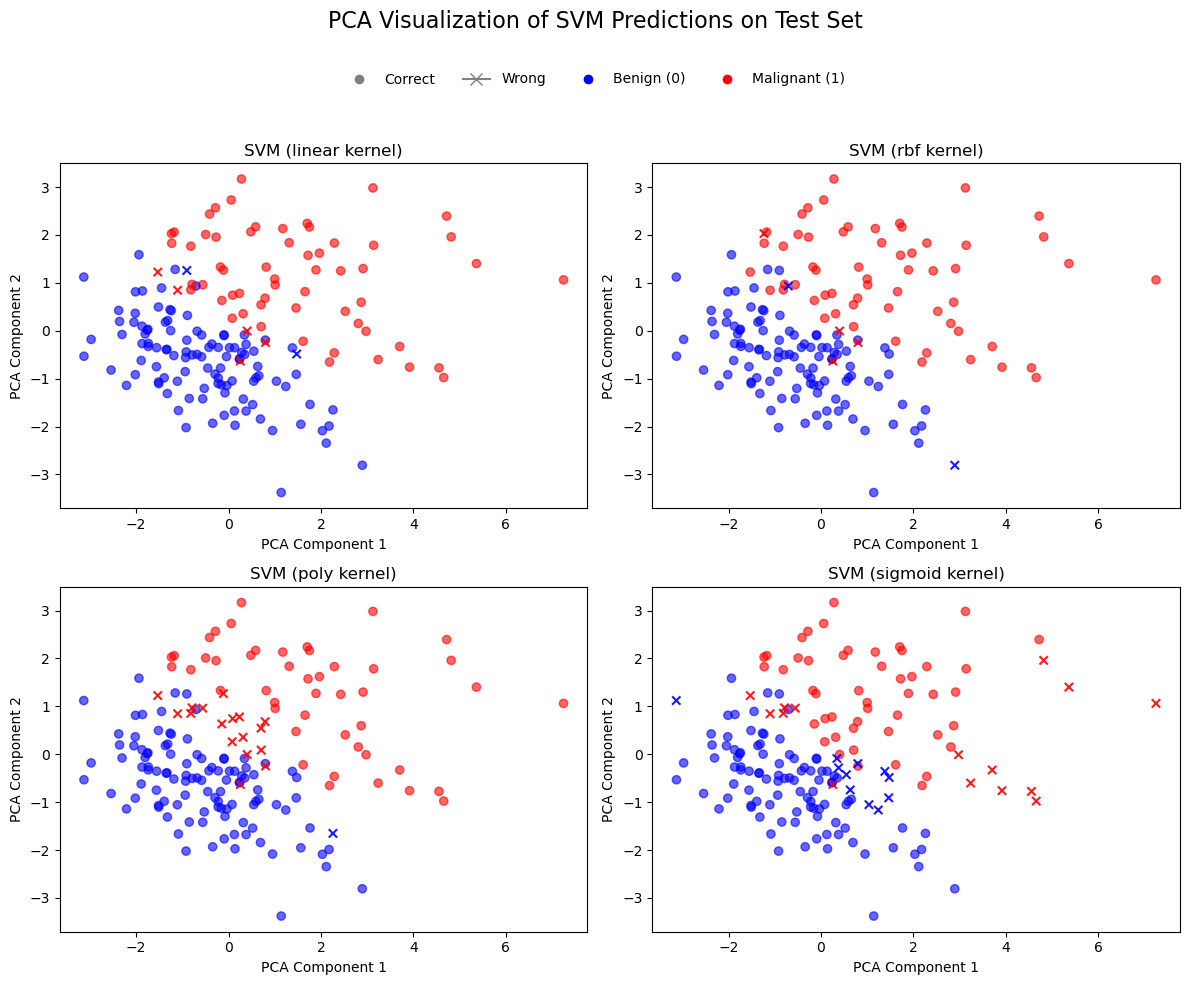

In [91]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.svm import SVC

# 核函数列表
kernels = ["linear", "rbf", "poly", "sigmoid"]

# PCA：只在训练集 fit，避免信息泄漏
pca = PCA(n_components=2)
X_train_pca = pca.fit_transform(X_train)
X_test_pca = pca.transform(X_test)

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.ravel()

for ax, kernel in zip(axes, kernels):
    svm = SVC(kernel=kernel, random_state=42)
    svm.fit(X_train, y_train)
    y_pred = svm.predict(X_test)

    correct = (y_pred == y_test)

    # 真实标签颜色
    colors = np.where(y_test == 1, "red", "blue")

    # 正确预测
    ax.scatter(
        X_test_pca[correct, 0],
        X_test_pca[correct, 1],
        c=colors[correct],
        alpha=0.6,
        marker="o"
    )

    # 错误预测
    ax.scatter(
        X_test_pca[~correct, 0],
        X_test_pca[~correct, 1],
        c=colors[~correct],
        alpha=0.9,
        marker="x"
    )

    ax.set_title(f"SVM ({kernel} kernel)")
    ax.set_xlabel("PCA Component 1")
    ax.set_ylabel("PCA Component 2")

# 构造统一图例
handles = [
    plt.Line2D([0], [0], marker='o', color='w', label='Correct',
               markerfacecolor='gray', markersize=8),
    plt.Line2D([0], [0], marker='x', color='gray', label='Wrong',
               markersize=8),
    plt.Line2D([0], [0], marker='o', color='w', label='Benign (0)',
               markerfacecolor='blue', markersize=8),
    plt.Line2D([0], [0], marker='o', color='w', label='Malignant (1)',
               markerfacecolor='red', markersize=8)
]

# 主标题（稍微往上提）
plt.suptitle(
    "PCA Visualization of SVM Predictions on Test Set",
    fontsize=16,
    y=0.98
)

# 图例：放在标题正下方
fig.legend(
    handles=handles,
    loc="upper center",
    bbox_to_anchor=(0.5, 0.93),
    ncol=4,
    frameon=False
)

# 给顶部留出空间
plt.tight_layout(rect=[0, 0, 1, 0.90])
plt.show()
